In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, laplace
import pandas as pd

In [2]:
def Prior(b, alpha, beta):
    return gamma.pdf(b, alpha, scale=1/beta)


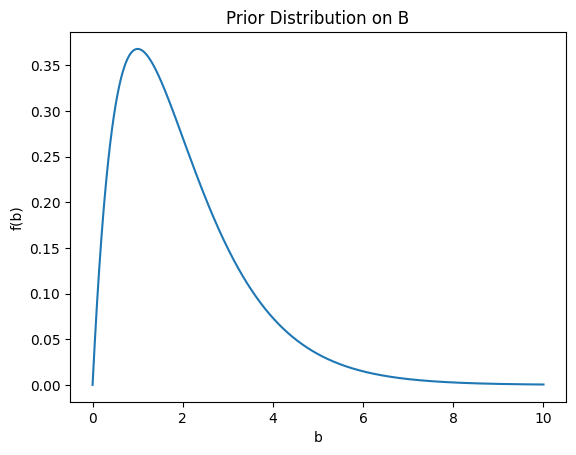

In [3]:

b_array = np.linspace(0,10,1000)
alpha = 2
beta = 1
p_plot = [Prior(b, alpha, beta) for b in b_array]

plt.plot(b_array,p_plot)
plt.title('Prior Distribution on B')
plt.xlabel('b')
plt.ylabel('f(b)')
plt.show()

In [ ]:
data = pd.read_excel(r'Path to your data here!')
data = data['Return'].to_numpy()
mean_data = np.mean(data)
data = (data - mean_data)*100


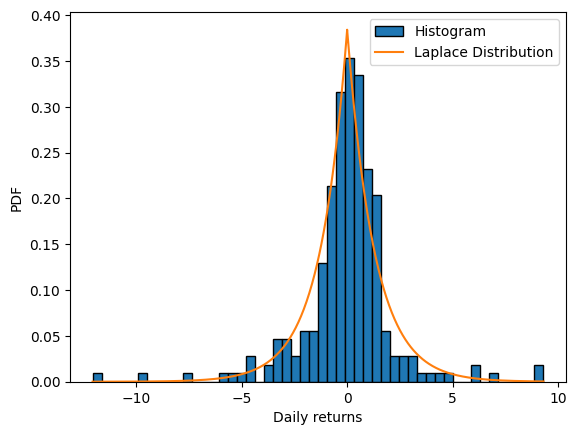

In [ ]:
x = np.linspace(min(data), max(data), 1000)
mean, b = 0, 1.4
pdf_values = laplace.pdf(x, mean, b)

plt.hist(data, bins = 50, density = True, edgecolor = 'black', label = ('Histogram'))
plt.plot(x, pdf_values, label='Laplace Distribution')
plt.xlabel('Daily returns')
plt.ylabel('PDF')
plt.legend()

plt.show()

MCMC Algorithm
- Definition of Posterior Distribution

In [ ]:
def Posterior(b, data, alpha, beta):
    # Calculation of the prior probability using a Gamma distribution.
    prior_prob = np.log(gamma.pdf(b, alpha, scale=1/beta))
    # The Laplace distribution is centered at 0 with a scale parameter b.
    likelihood_prob = np.log(np.sum(laplace.pdf(data, 0, b)))
    
    return prior_prob + likelihood_prob

- MCMC Metropolis Hastings

In [ ]:
# Initialize the array to store the scale parameter b values and set the initial value
b_array = np.zeros(100000)
b_array[0] = 1

# Initialize the count for accepted proposals
acceptance = 0

# Define the standard deviation for the proposal distribution's jumps
jump_std = 0.12

# Iterate over the length of the b_array to generate samples
for i in range(1, len(b_array) - 1):
    
    # Propose a new value for b using a log-normal jump to ensure positivity
    b_proposed = np.exp(np.random.normal(np.log(b_array[i - 1]), jump_std))

    # Calculate the posterior probabilities for the current and proposed b values
    n1 = Posterior(b_array[i - 1], data, alpha, beta)
    n2 = Posterior(b_proposed, data, alpha, beta)

    # Calculate the acceptance ratio
    log_r = n2 - n1
    p_accept = min(log_r, 0)

    # Determine whether to accept the proposed value
    if p_accept > np.log(np.random.rand()):
        b_array[i] = b_proposed
        acceptance += 1
    else:
        b_array[i] = b_array[i - 1]

# Calculate and print the acceptance rate over the entire chain
acceptance_rate = acceptance / len(b_array)

In [8]:
#Thinning on the results
#Getting rid of the first 25% values and taking every third value.
b_thinned = b_array[25000::3]


- Plotting the results

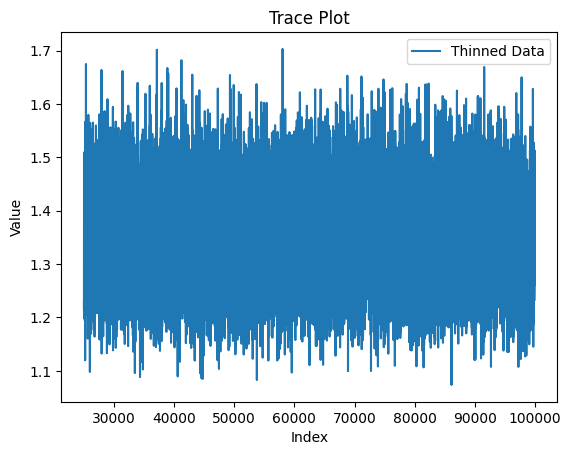

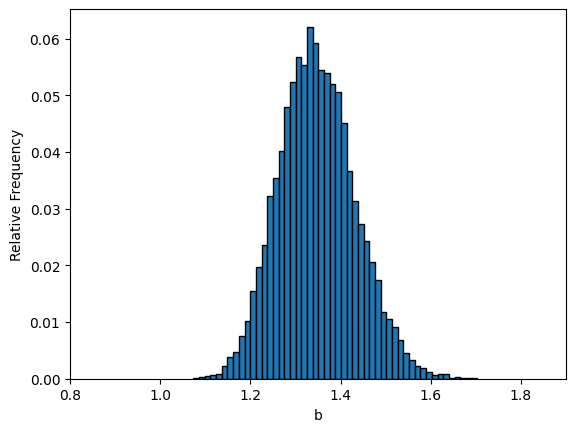

In [9]:
original_indices = np.arange(len(b_array))
thinned_indices = np.arange(25000, len(b_array), 3)

# Plot thinned data
plt.plot(thinned_indices, b_thinned, label='Thinned Data')

# Adding labels and legend
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Trace Plot')
plt.legend()
# Display the plot
plt.show()


#Histogram Plot
plt.hist(b_thinned, bins = 50, edgecolor = 'black', label = ('Histogram'), weights=np.ones(len(b_thinned)) / len(b_thinned), density=False)
plt.xlim(0.8,1.9)
plt.xlabel('b')
plt.ylabel('Relative Frequency')
plt.show()


In [10]:
b_mean = np.mean(b_thinned)
b_std = np.std(b_thinned)

print(f'The mean for the parameter b is {np.round(b_mean,4)}. \n The standard deviation is {np.round(b_std,3)}.\n The total acceptance rate of {np.round(acceptance_rate,3)}')


The mean for the parameter b is 1.3479. 
 The standard deviation is 0.085.
 The total acceptance rate of 0.515
